In [1]:
from src.ffnn import *
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Evaluation
from sklearn.metrics import classification_report, f1_score, confusion_matrix, ConfusionMatrixDisplay
data = pd.read_csv('datasetml_2026.csv')


In [2]:
data.head()

,cgpa,backlogs,college_tier,country,university_ranking_band,internship_count,aptitude_score,communication_score,specialization,industry,internship_quality_score,placement_status
0,7.397371,1,Tier 2,Canada,100-300,2,53.574150,64.177062,Data Science,Consulting,5.481450,Placed
1,6.889389,0,Tier 3,UK,300+,1,60.687750,88.346052,Data Science,Consulting,4.625099,Placed
2,7.518151,0,Tier 1,UK,100-300,2,64.568750,69.493171,Cybersecurity,Healthcare,5.227939,Placed
3,8.218424,0,Tier 2,UK,100-300,3,73.461500,78.204854,AI/ML,Tech,5.150674,Placed
4,6.812677,1,Tier 2,USA,100-300,4,86.518121,44.680881,Data Science,Consulting,3.888824,Placed


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   cgpa                      10000 non-null  float64
 1   backlogs                  10000 non-null  int64  
 2   college_tier              10000 non-null  object 
 3   country                   10000 non-null  object 
 4   university_ranking_band   10000 non-null  object 
 5   internship_count          10000 non-null  int64  
 6   aptitude_score            10000 non-null  float64
 7   communication_score       10000 non-null  float64
 8   specialization            10000 non-null  object 
 9   industry                  10000 non-null  object 
 10  internship_quality_score  10000 non-null  float64
 11  placement_status          10000 non-null  object 
dtypes: float64(4), int64(2), object(6)
memory usage: 937.6+ KB


In [4]:
data.describe()

,cgpa,backlogs,internship_count,aptitude_score,communication_score,internship_quality_score
count,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,6.998290,1.248100,1.49930,69.877531,65.158600,5.021436
std,0.802606,1.149904,1.20289,14.700532,14.740446,1.505975
min,4.000000,0.000000,0.00000,30.000000,30.000000,1.000000
25%,6.461928,0.000000,1.00000,59.880399,55.112244,4.012656
50%,6.997924,1.000000,1.00000,70.097368,65.006484,5.017335
75%,7.536865,2.000000,2.00000,80.213934,75.277248,6.031400
max,10.000000,6.000000,5.00000,100.000000,100.000000,10.000000


In [5]:
# Cek missing values
missing = data.isnull().sum()
missing_pct = (missing / len(data) * 100).round(2)
pd.DataFrame({'Missing Count': missing, 'Missing (%)': missing_pct})

,Missing Count,Missing (%)
cgpa,0,0.0
backlogs,0,0.0
college_tier,0,0.0
country,0,0.0
university_ranking_band,0,0.0
internship_count,0,0.0
aptitude_score,0,0.0
communication_score,0,0.0
specialization,0,0.0
industry,0,0.0


placement_status
Placed        6153
Not Placed    3847
Name: count, dtype: int64


<Axes: xlabel='count', ylabel='placement_status'>

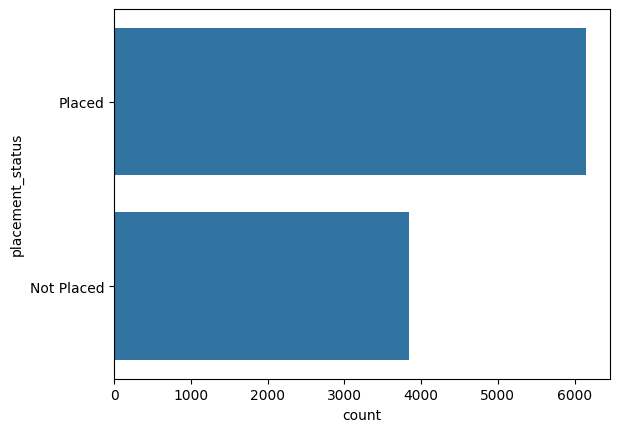

In [6]:
print(data['placement_status'].value_counts())

sns.countplot(data['placement_status'])

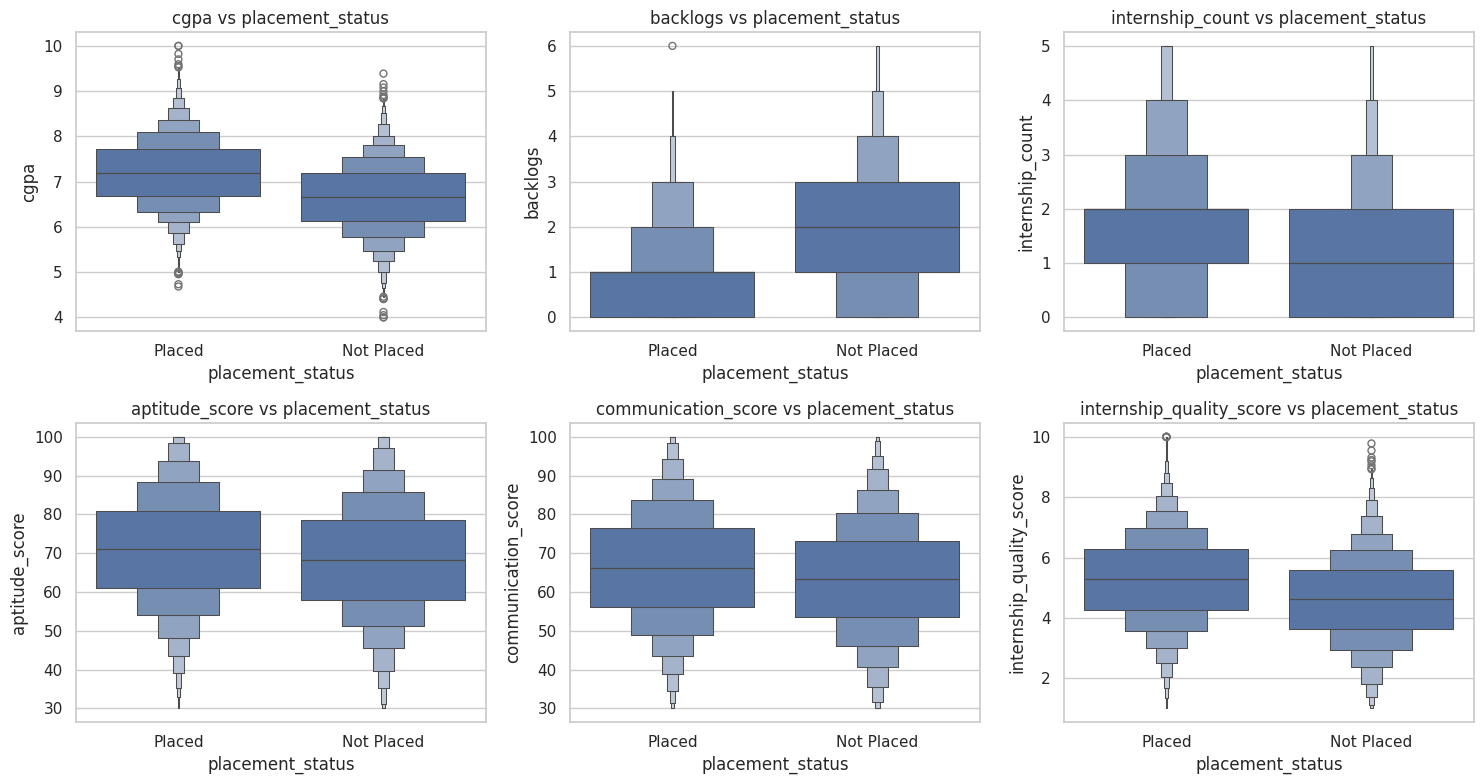

In [21]:
import math
numerical_cols = data.select_dtypes(include=["int64", "float64"]).columns.tolist()
n_cols = 3 
n_rows = math.ceil(len(numerical_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxenplot(
        data=data,
        x='placement_status',
        y=col,
        ax=axes[i]
    )
    axes[i].set_title(f"{col} vs placement_status")
    axes[i].set_xlabel('placement_status')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

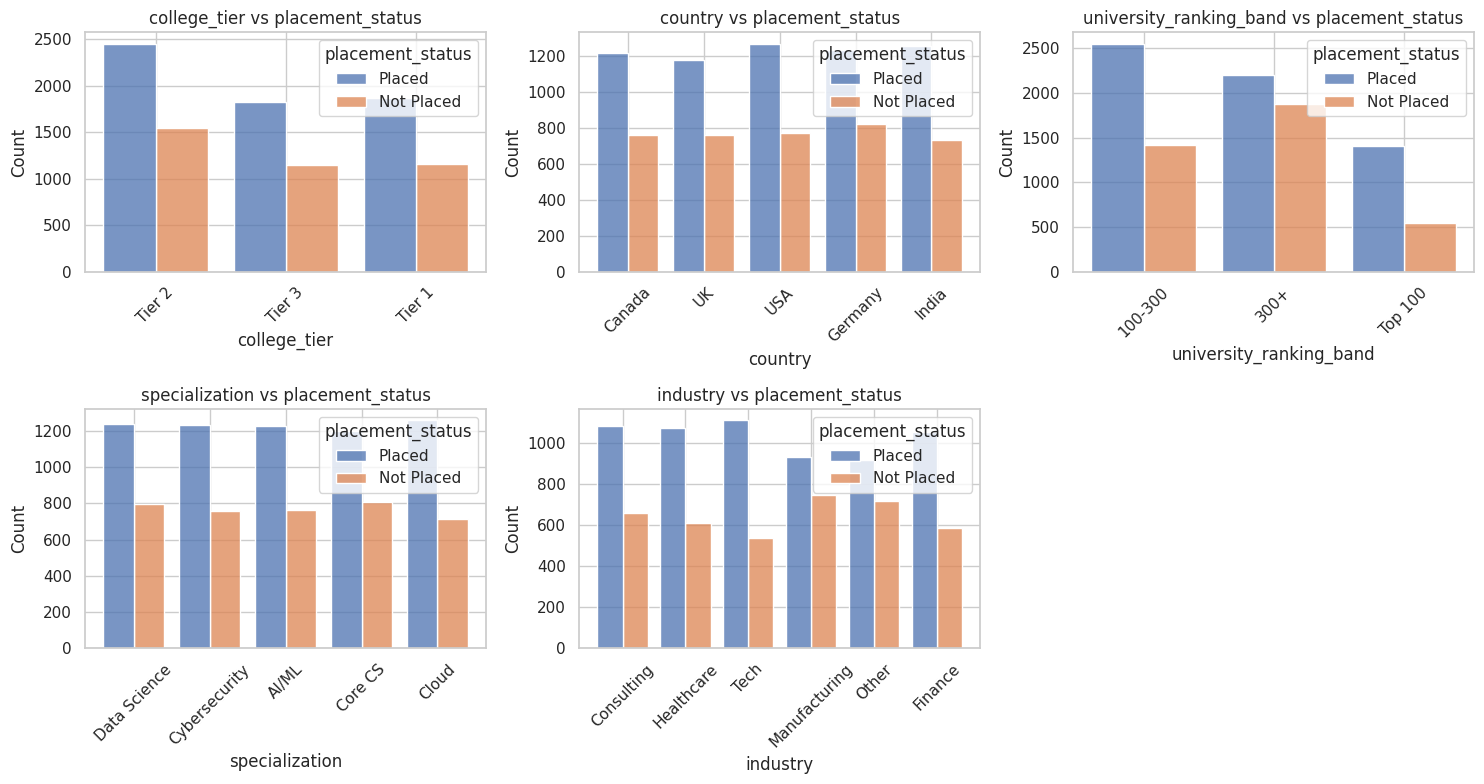

In [29]:
categorical_cols = data.select_dtypes(include=["object", "category"]).columns.tolist()
categorical_cols.remove('placement_status')
n_cols = 3
n_rows = math.ceil(len(categorical_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.histplot(
        data=data,
        x=col,
        hue='placement_status',
        multiple="dodge",
        shrink=0.8,
        discrete=True,
        ax=axes[i]
    )
    
    axes[i].set_title(f"{col} vs placement_status")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis='x', rotation=45)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

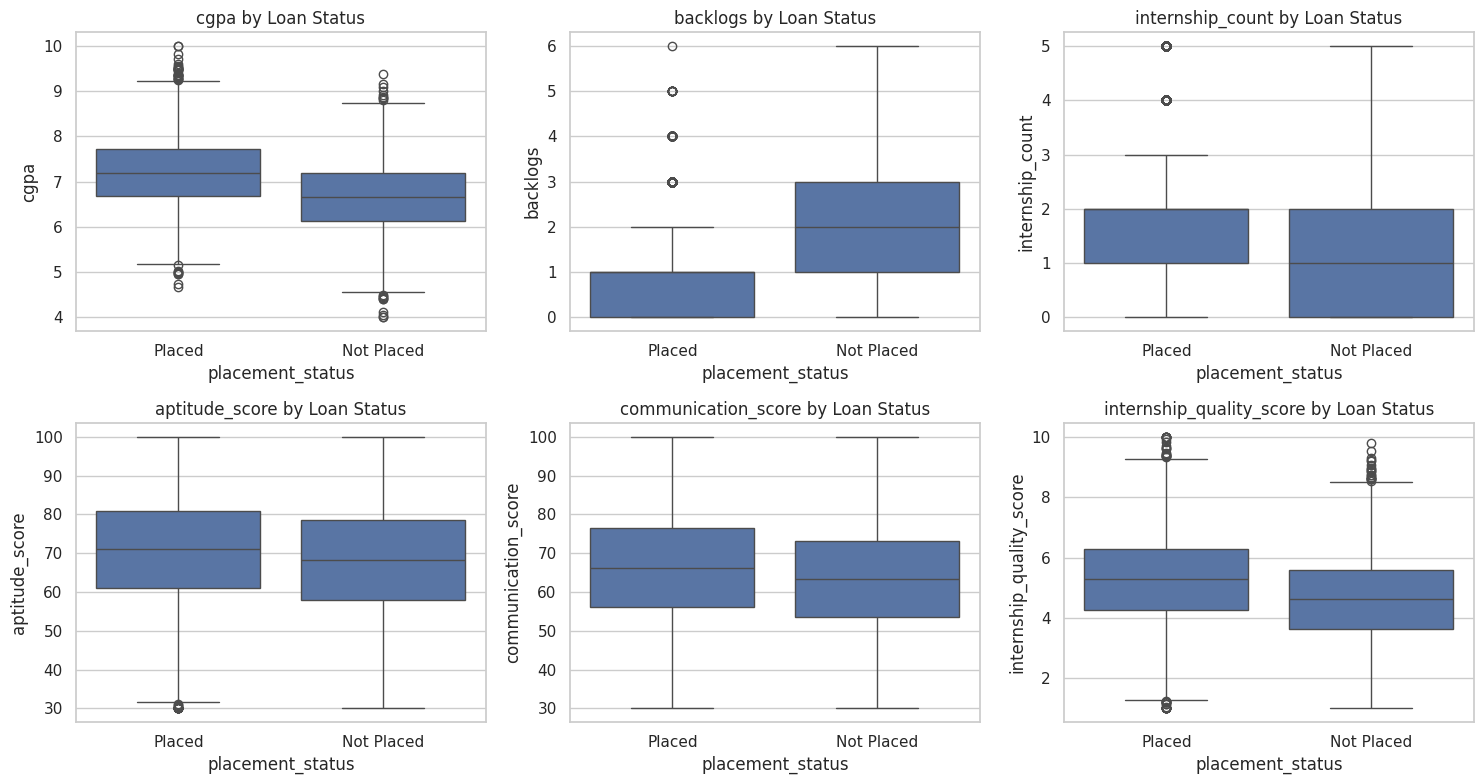

In [37]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), numerical_cols):
    sns.boxplot(data=data, x='placement_status', y=col, ax=ax)
    ax.set_title(f'{col} by Loan Status')

plt.tight_layout()
plt.show()

In [107]:
TARGET_COL = 'placement_status'

print("Categorical:", categorical_cols + ['placement_status'])
print("Numerical:  ", numerical_cols)

# Buat salinan
train = data.copy()
test  = data.copy()


Categorical: ['college_tier', 'country', 'university_ranking_band', 'specialization', 'industry', 'placement_status']
Numerical:   ['cgpa', 'backlogs', 'internship_count', 'aptitude_score', 'communication_score', 'internship_quality_score']


In [73]:
def get_iqr_bounds(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

for col in numerical_cols:
    lower, upper = get_iqr_bounds(train[col])
    n = ((train[col] < lower) | (train[col] > upper)).sum()
    print(f"{col}: {n} outliers")


cgpa: 83 outliers
backlogs: 29 outliers
internship_count: 662 outliers
aptitude_score: 0 outliers
communication_score: 0 outliers
internship_quality_score: 36 outliers


In [108]:
train["placement_status"] = train["placement_status"].map({
    "Placed": 1,
    "Not Placed": 0
})
test["placement_status"] = test["placement_status"].map({
    "Placed": 1,
    "Not Placed": 0
})
train = pd.get_dummies(train, columns=categorical_cols, drop_first=True).astype('float32')
test  = pd.get_dummies(test,  columns=categorical_cols, drop_first=True).astype('float32')
feat_cols = [c for c in train.columns if c not in [TARGET_COL]]
test = test.reindex(columns=feat_cols, fill_value=0)

In [109]:
feature_cols = [c for c in train.columns if c not in [TARGET_COL]]

X            = train[feature_cols]
y            = train[TARGET_COL]
X_test_final = test[feature_cols]

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_val:  ", X_val.shape,   "| y_val:  ", y_val.shape)

X_train: (8000, 23) | y_train: (8000,)
X_val:   (2000, 23) | y_val:   (2000,)


In [110]:
results = {}

def evaluate_model(model, X_val, y_val, model_name="Model"):
    y_pred = model.predict(X_val)
    print(f"{'='*55}")
    print(f"  {model_name}")
    print(f"{'='*55}")
    print(classification_report(y_val, y_pred,
                                target_names=['placed (0)', 'not placed (1)']))
    macro_f1 = f1_score(y_val, y_pred, average='macro')
    print(f">>> Macro F1-Score: {macro_f1:.4f}\n")
    return macro_f1

In [117]:
train.info()
model = FFNN([24,12,6,3,1], [Tanh, Tanh, Tanh, Sigmoid])
model.train(train.to_numpy())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 24 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   cgpa                             10000 non-null  float32
 1   backlogs                         10000 non-null  float32
 2   internship_count                 10000 non-null  float32
 3   aptitude_score                   10000 non-null  float32
 4   communication_score              10000 non-null  float32
 5   internship_quality_score         10000 non-null  float32
 6   placement_status                 10000 non-null  float32
 7   college_tier_Tier 2              10000 non-null  float32
 8   college_tier_Tier 3              10000 non-null  float32
 9   country_Germany                  10000 non-null  float32
 10  country_India                    10000 non-null  float32
 11  country_UK                       10000 non-null  float32
 12  country_USA        

TypeError: FFNN.train() missing 2 required positional arguments: 'y' and 'epochs'